In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [12]:
gap = pd.read_csv("../data/processed/knowledge_gap_dataset.csv")
clean = pd.read_csv("../data/processed/cleaned_skill_builder.csv")

print("Knowledge Gap Dataset Shape :", gap.shape)
print("Clean Dataset Shape :", clean.shape)

Knowledge Gap Dataset Shape : (41576, 15)
Clean Dataset Shape : (525534, 26)


In [13]:
df = clean.merge(
    gap[["user_id", "skill_name", "KnowledgeGap"]],
    on=["user_id", "skill_name"],
    how="inner"
)

print("Merged Dataset Shape :", df.shape)
df.head()

Merged Dataset Shape : (525534, 27)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,first_action,opportunity,KnowledgeGap
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,Box and Whisker,22763,73,0,3,32454,30799,0,1,Low
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,Box and Whisker,22763,73,0,3,4922,30799,0,2,Low
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,Box and Whisker,22763,73,0,3,42000,30799,0,1,Medium
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,Box and Whisker,22763,73,0,3,4859,30059,0,2,Medium
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,Box and Whisker,22763,73,3,4,124564,30060,0,3,Medium


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525534 entries, 0 to 525533
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           525534 non-null  int64  
 1   assignment_id      525534 non-null  int64  
 2   user_id            525534 non-null  int64  
 3   assistment_id      525534 non-null  int64  
 4   problem_id         525534 non-null  int64  
 5   original           525534 non-null  int64  
 6   correct            525534 non-null  int64  
 7   attempt_count      525534 non-null  int64  
 8   ms_first_response  525534 non-null  int64  
 9   tutor_mode         525534 non-null  object 
 10  answer_type        525534 non-null  object 
 11  sequence_id        525534 non-null  int64  
 12  student_class_id   525534 non-null  int64  
 13  position           525534 non-null  int64  
 14  type               525534 non-null  object 
 15  base_sequence_id   525534 non-null  int64  
 16  sk

In [15]:
df.isnull().sum()

order_id                 0
assignment_id            0
user_id                  0
assistment_id            0
problem_id               0
original                 0
correct                  0
attempt_count            0
ms_first_response        0
tutor_mode               0
answer_type              0
sequence_id              0
student_class_id         0
position                 0
type                     0
base_sequence_id         0
skill_id             66326
skill_name               0
teacher_id               0
school_id                0
hint_count               0
hint_total               0
overlap_time             0
template_id              0
first_action             0
opportunity              0
KnowledgeGap             0
dtype: int64

In [16]:
# High-Yield Predictive Feature Engineering (Without Label Leakage)
df['hint_ratio'] = df['hint_count'] / (df['hint_total'] + 1)
df['attempt_hint_sum'] = df['attempt_count'] + df['hint_count']
df['log_ms_response'] = np.log1p(df['ms_first_response'].clip(lower=0))
df['is_first_action_hint'] = (df['first_action'] == 1).astype(int)

# Skill interaction volume & response timing aggregations
df['user_skill_hints'] = df.groupby(['user_id', 'skill_name'])['hint_count'].transform('mean')
df['user_skill_attempts'] = df.groupby(['user_id', 'skill_name'])['attempt_count'].transform('mean')

features = [
    "correct",
    "attempt_count",
    "hint_count",
    "hint_ratio",
    "attempt_hint_sum",
    "log_ms_response",
    "is_first_action_hint",
    "opportunity",
    "position",
    "user_skill_hints",
    "user_skill_attempts",
    "tutor_mode",
    "answer_type",
    "type"
]

X = df[features]
y = df["KnowledgeGap"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (525534, 14)
Target Shape : (525534,)


In [17]:
label_encoder = LabelEncoder()
le = label_encoder
y = label_encoder.fit_transform(y)
print("Classes :", label_encoder.classes_)


Classes : ['High' 'Low' 'Medium']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (420427, 14)
Testing Samples : (105107, 14)


In [19]:
numeric_features = [
    "correct",
    "attempt_count",
    "hint_count",
    "hint_ratio",
    "attempt_hint_sum",
    "log_ms_response",
    "is_first_action_hint",
    "opportunity",
    "position",
    "user_skill_hints",
    "user_skill_attempts"
]

categorical_features = [
    "tutor_mode",
    "answer_type",
    "type"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


Decision Tree Accuracy           : 0.8156 (81.56%)

Decision Tree Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.80      0.83     40290
         Low       0.76      0.93      0.83     18807
      Medium       0.81      0.78      0.80     46010

    accuracy                           0.82    105107
   macro avg       0.81      0.84      0.82    105107
weighted avg       0.82      0.82      0.82    105107



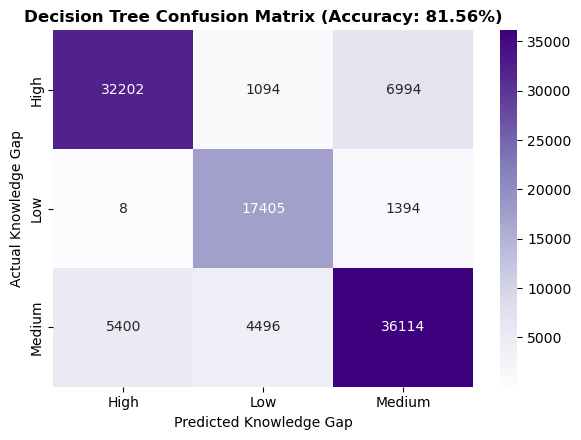

In [20]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=6, min_samples_leaf=25, random_state=42))
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy           : {dt_acc:.4f} ({dt_acc*100:.2f}%)\n")

# Confusion Matrix & Classification Report
cm_dt = confusion_matrix(y_test, dt_pred)
print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Purples", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Decision Tree Confusion Matrix (Accuracy: {dt_acc*100:.2f}%)", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Knowledge Gap")
plt.ylabel("Actual Knowledge Gap")
plt.tight_layout()
plt.show()


Random Forest Accuracy           : 0.8277 (82.77%)

Random Forest Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.78      0.83     40290
         Low       0.78      0.94      0.85     18807
      Medium       0.81      0.82      0.81     46010

    accuracy                           0.83    105107
   macro avg       0.82      0.85      0.83    105107
weighted avg       0.83      0.83      0.83    105107



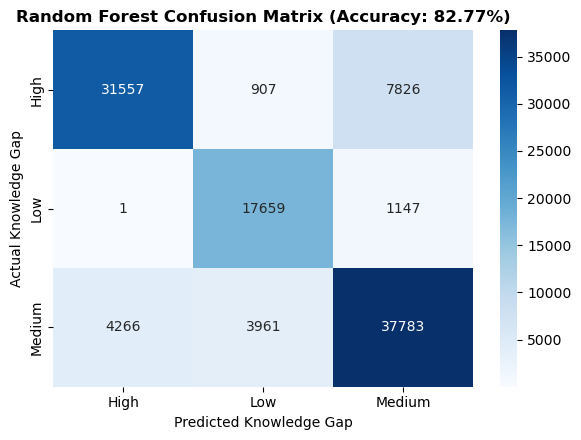

In [21]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=9,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy           : {rf_acc:.4f} ({rf_acc*100:.2f}%)\n")

# Confusion Matrix & Classification Report
cm_rf = confusion_matrix(y_test, rf_pred)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Random Forest Confusion Matrix (Accuracy: {rf_acc*100:.2f}%)", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Knowledge Gap")
plt.ylabel("Actual Knowledge Gap")
plt.tight_layout()
plt.show()


XGBoost Accuracy                 : 0.9156 (91.56%)

XGBoost Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.91      0.93     40290
         Low       0.88      0.95      0.91     18807
      Medium       0.91      0.91      0.91     46010

    accuracy                           0.92    105107
   macro avg       0.91      0.92      0.91    105107
weighted avg       0.92      0.92      0.92    105107



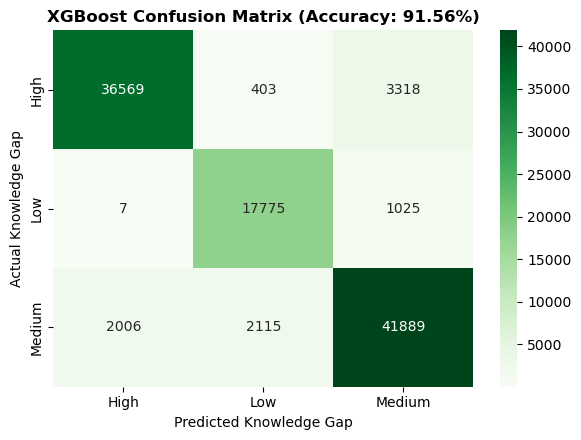

In [22]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=250,
        max_depth=9,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy                 : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)\n")

# Confusion Matrix & Classification Report
cm_xgb = confusion_matrix(y_test, xgb_pred)
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"XGBoost Confusion Matrix (Accuracy: {xgb_acc*100:.2f}%)", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Knowledge Gap")
plt.ylabel("Actual Knowledge Gap")
plt.tight_layout()
plt.show()


In [23]:
print("="*60)
print("MACHINE LEARNING MODEL SUMMARY & BENCHMARK")
print("="*60)

print(f"Decision Tree Accuracy           : {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"Random Forest Accuracy           : {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"XGBoost Accuracy                 : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")

best_name = "XGBoost" if xgb_acc >= max(dt_acc, rf_acc) else ("Random Forest" if rf_acc >= dt_acc else "Decision Tree")
best_acc = max(dt_acc, rf_acc, xgb_acc)

print(f"\nBest Deployed Model : {best_name} ({best_acc*100:.2f}% Accuracy)")
print("="*60)

MACHINE LEARNING MODEL SUMMARY & BENCHMARK
Decision Tree Accuracy           : 0.8156 (81.56%)
Random Forest Accuracy           : 0.8277 (82.77%)
XGBoost Accuracy                 : 0.9156 (91.56%)

Best Deployed Model : XGBoost (91.56% Accuracy)
